In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\2) Stock Prices Data Set.csv')
print(df.head())
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391
(497472, 7)
['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']
symbol        str
date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv(r'C:\Users\sandu\Downloads\Data Set For Task\2) Stock Prices Data Set.csv')

# Filter only Apple (AAPL) stock
apple = df[df['symbol'] == 'AAPL'].copy()

# Convert date column to proper date format
apple['date'] = pd.to_datetime(apple['date'])

# Sort by date
apple = apple.sort_values('date')

print(apple.head())
print(apple.shape)

     symbol       date     open     high      low    close     volume
1      AAPL 2014-01-02  79.3828  79.5756  78.8601  79.0185   58791957
484    AAPL 2014-01-03  78.9799  79.0999  77.2042  77.2828   98303870
967    AAPL 2014-01-06  76.7785  78.1142  76.2285  77.7042  103359151
1450   AAPL 2014-01-07  77.7599  77.9942  76.8464  77.1481   79432766
1933   AAPL 2014-01-08  76.9728  77.9371  76.9556  77.6371   64686685
(1007, 7)


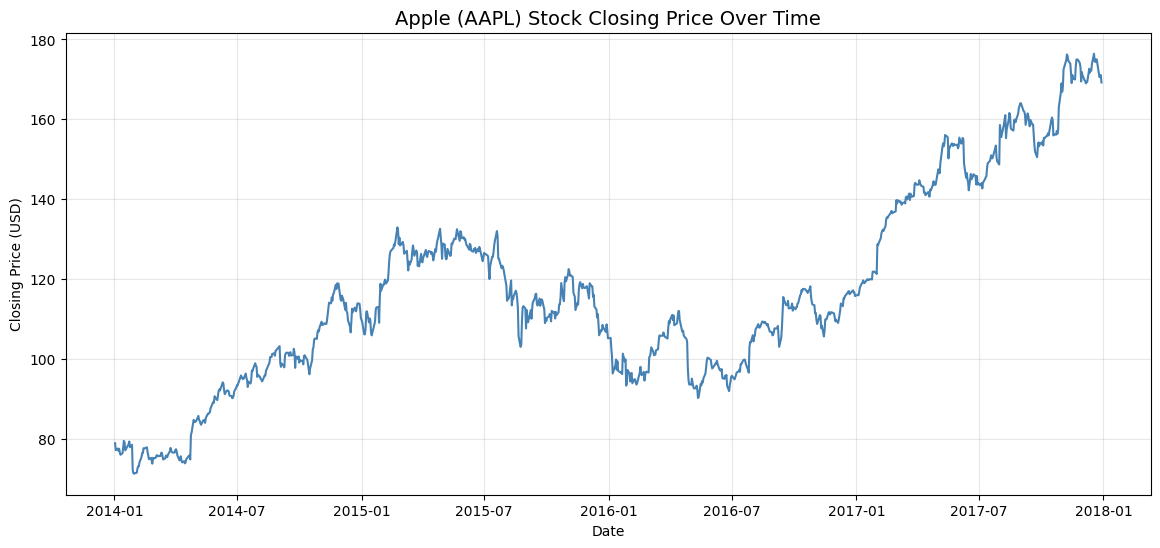

Stock price chart saved!


In [4]:
#plot stock price over time
plt.figure(figsize=(14, 6))
plt.plot(apple['date'], apple['close'], color='steelblue', linewidth=1.5)
plt.title('Apple (AAPL) Stock Closing Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\stock_price.png')
plt.show()
print("Stock price chart saved!")

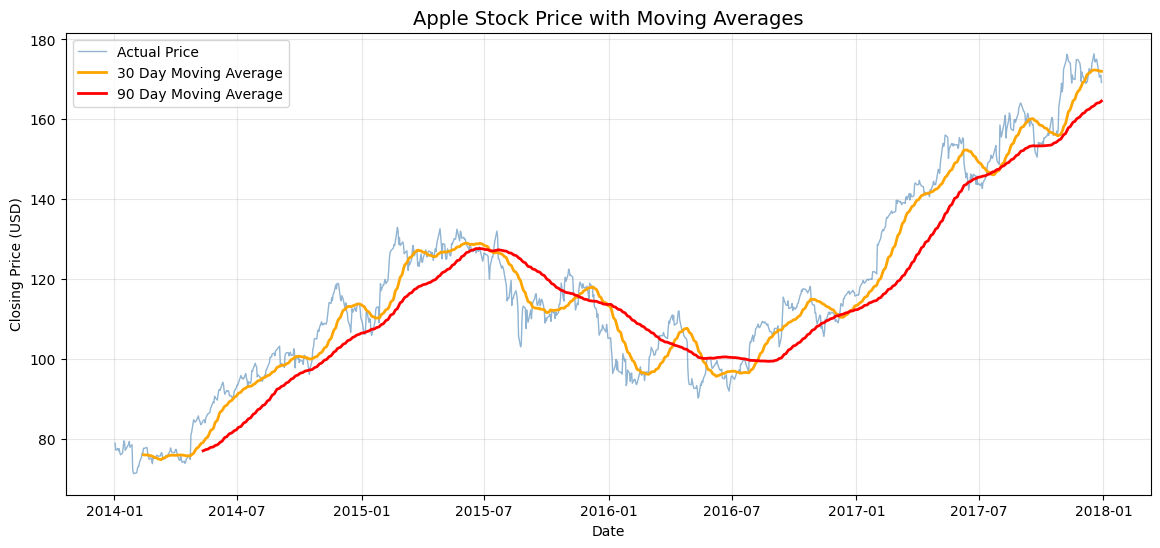

Moving average chart saved!


In [5]:

# Calculate moving averages
apple['MA_30'] = apple['close'].rolling(window=30).mean()   # 30 day average
apple['MA_90'] = apple['close'].rolling(window=90).mean()   # 90 day average

plt.figure(figsize=(14, 6))
plt.plot(apple['date'], apple['close'], color='steelblue', linewidth=1, label='Actual Price', alpha=0.6)
plt.plot(apple['date'], apple['MA_30'], color='orange', linewidth=2, label='30 Day Moving Average')
plt.plot(apple['date'], apple['MA_90'], color='red', linewidth=2, label='90 Day Moving Average')
plt.title('Apple Stock Price with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\moving_average.png')
plt.show()
print("Moving average chart saved!")

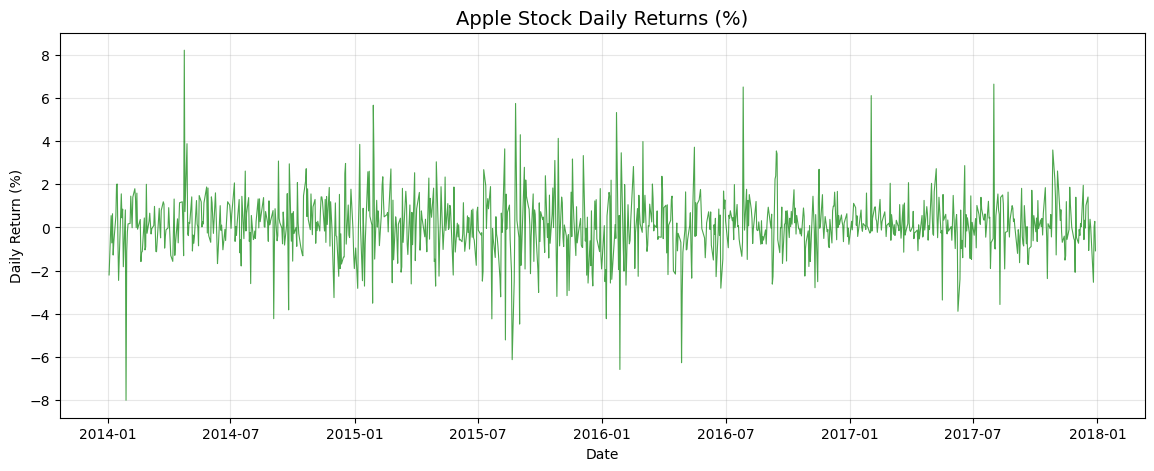

Daily returns chart saved!


In [9]:
# Calculate daily returns
apple['daily_return'] = apple['close'].pct_change() * 100

plt.figure(figsize=(14, 5))
plt.plot(apple['date'], apple['daily_return'], color='green', linewidth=0.8, alpha=0.7)
plt.title('Apple Stock Daily Returns (%)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\daily_returns.png')
plt.show()
print("Daily returns chart saved!")

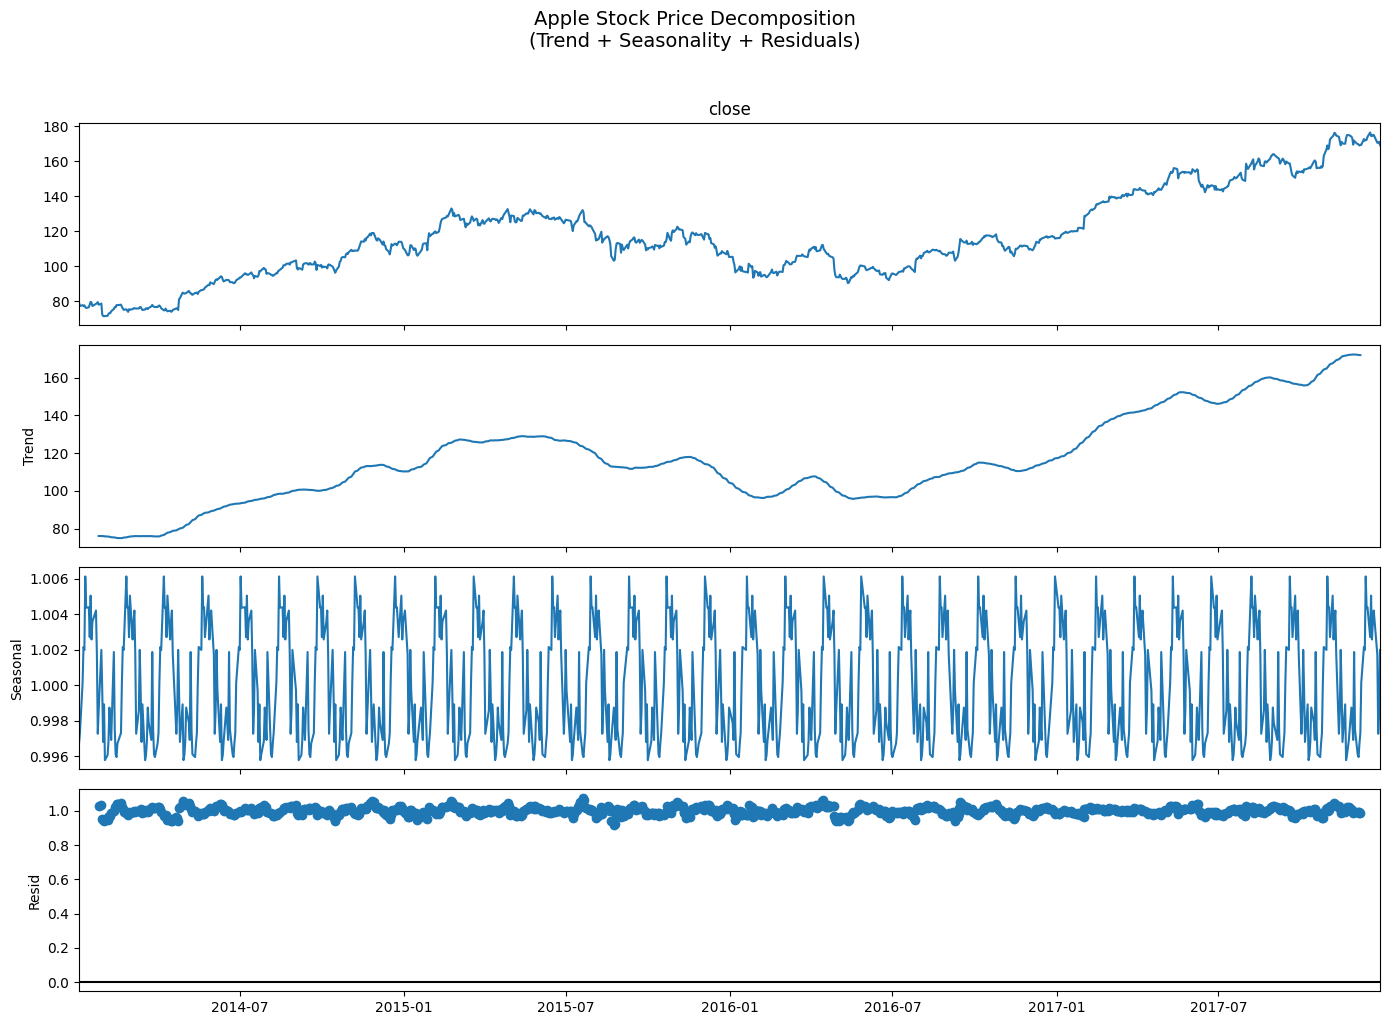

Decomposition chart saved!


In [10]:
# Set date as index for decomposition
apple_indexed = apple.set_index('date')['close']

# Decompose the time series
decomposition = seasonal_decompose(apple_indexed, model='multiplicative', period=30)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Apple Stock Price Decomposition\n(Trend + Seasonality + Residuals)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\decomposition.png')
plt.show()
print("Decomposition chart saved!")

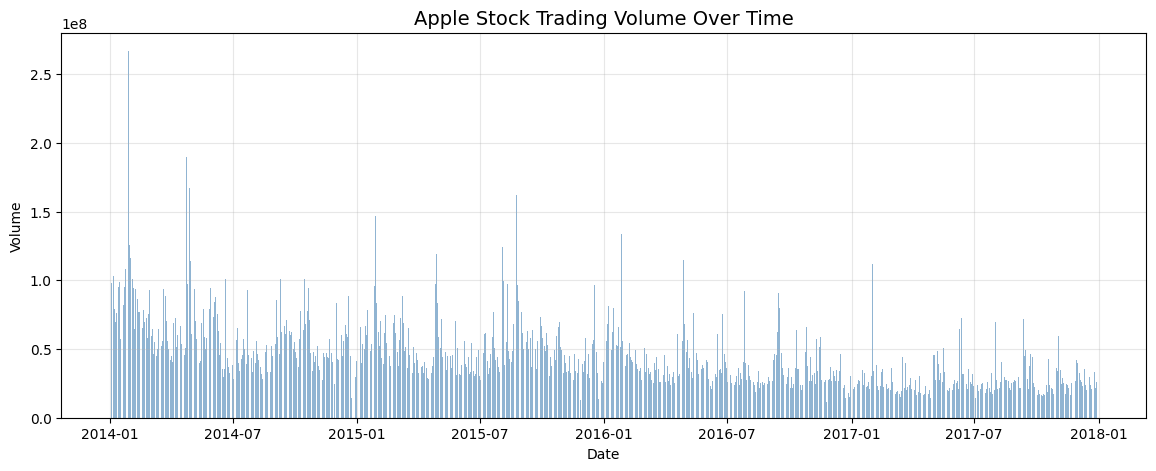

Volume chart saved!


In [13]:
#volume analysis

plt.figure(figsize=(14, 5))
plt.bar(apple['date'], apple['volume'], color='steelblue', alpha=0.6, width=1)
plt.title('Apple Stock Trading Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.savefig(r'C:\Users\sandu\Downloads\Intern - Codveda Technologies\Level 2\volume.png')
plt.show()
print("Volume chart saved!")